# Exploratory Data Analysis — UCI SMS Spam Collection

**Master's Thesis:** Comparative Evaluation of Classical Machine Learning and Transformer-Based Models for SMS Spam Detection  
**Author:** Michał Pokracki  
**Notebook:** 01 — Exploratory Data Analysis

## Purpose

This notebook performs the initial exploration of the UCI SMS Spam Collection dataset, which will serve as the basis for the comparative evaluation of classical machine learning models and a transformer-based model in subsequent notebooks.

The goals of this notebook are:
1. Load the dataset and verify its structure.
2. Inspect the class distribution (ham vs spam).
3. Analyse basic textual characteristics (message length, word count).
4. Look at representative examples of each class.
5. Identify any data quality issues that need addressing during preprocessing.

> **Terminology.** Each message is labelled either **spam** (an unsolicited message) or **ham**. *Ham* is the standard term in the spam-filtering literature for a legitimate, non-spam message — an ordinary message the user actually wants to receive.

## 1. Setup

In [1]:
import io
import ssl
import zipfile
import urllib.request

import certifi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Plot styling
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('Setup complete.')

Setup complete.


## 2. Load the Dataset

In [2]:
# Load the SMS Spam Collection dataset directly from the UCI archive.
# The dataset is distributed as a zipped, tab-separated file (label<TAB>message).
# Note: ucimlrepo does not currently expose dataset id=228 for direct import,
# so we fetch the official archive and parse it ourselves.
UCI_URL = 'https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip'

ssl_context = ssl.create_default_context(cafile=certifi.where())
with urllib.request.urlopen(UCI_URL, context=ssl_context, timeout=60) as response:
    archive = zipfile.ZipFile(io.BytesIO(response.read()))

with archive.open('SMSSpamCollection') as f:
    df = pd.read_csv(f, sep='\t', header=None, names=['label', 'message'])

print(f'Dataset shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Dataset shape: (5572, 2)
Columns: ['label', 'message']


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## 3. Class Distribution

The SMS Spam Collection is known to be class-imbalanced. Confirming the exact distribution is important because it informs the choice of evaluation metrics (accuracy alone is misleading on imbalanced datasets — precision, recall, F1 and ROC-AUC will be needed).

Absolute counts:
label
ham     4825
spam     747
Name: count, dtype: int64

Percentages:
label
ham     86.59
spam    13.41
Name: proportion, dtype: float64


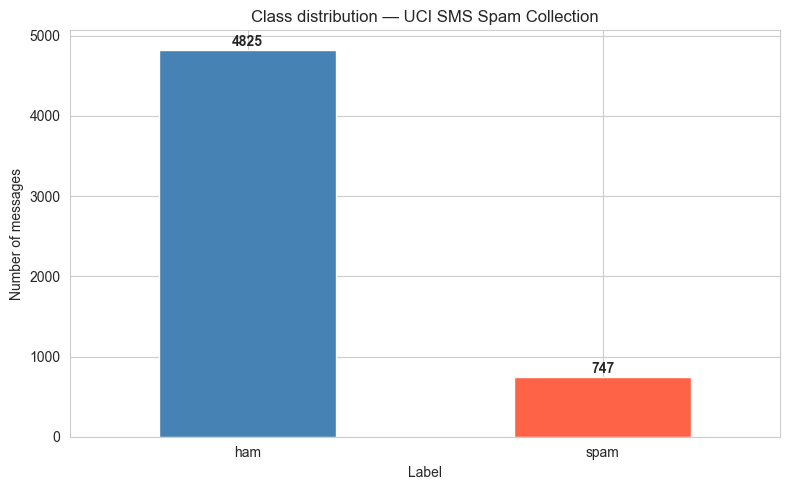

In [3]:
class_counts = df['label'].value_counts()
class_pct = df['label'].value_counts(normalize=True) * 100

print('Absolute counts:')
print(class_counts)
print('\nPercentages:')
print(class_pct.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
class_counts.plot(kind='bar', ax=ax, color=['steelblue', 'tomato'])
ax.set_title('Class distribution — UCI SMS Spam Collection')
ax.set_xlabel('Label')
ax.set_ylabel('Number of messages')
ax.set_xticklabels(class_counts.index, rotation=0)
for i, v in enumerate(class_counts.values):
    ax.text(i, v + 50, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Message Length Analysis

Spam and legitimate (ham) messages tend to differ in length. This is a useful preliminary signal and may even serve as a weak feature on its own.

In [4]:
df['char_count'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

print('Character count statistics by class:')
print(df.groupby('label')['char_count'].describe().round(2))
print('\nWord count statistics by class:')
print(df.groupby('label')['word_count'].describe().round(2))

Character count statistics by class:
        count    mean    std   min    25%    50%    75%    max
label                                                         
ham    4825.0   71.48  58.44   2.0   33.0   52.0   93.0  910.0
spam    747.0  138.67  28.87  13.0  133.0  149.0  157.0  223.0

Word count statistics by class:
        count   mean    std  min   25%   50%   75%    max
label                                                    
ham    4825.0  14.31  11.52  1.0   7.0  11.0  19.0  171.0
spam    747.0  23.91   5.78  2.0  22.0  25.0  28.0   35.0


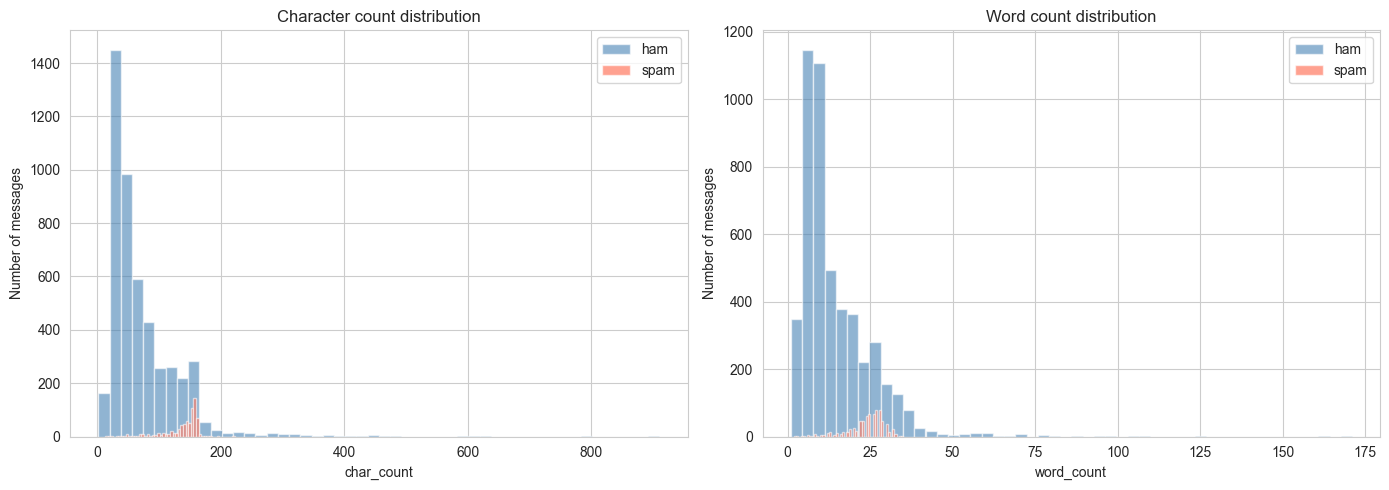

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ['char_count', 'word_count'],
    ['Character count distribution', 'Word count distribution']
):
    for label, color in [('ham', 'steelblue'), ('spam', 'tomato')]:
        subset = df[df['label'] == label][col]
        ax.hist(subset, bins=50, alpha=0.6, label=label, color=color)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.set_ylabel('Number of messages')
    ax.legend()

plt.tight_layout()
plt.show()

## 5. Sample Inspection

Looking at a few representative examples from each class helps build intuition about the lexical patterns involved.

In [6]:
print('=' * 80)
print('Sample ham messages:')
print('=' * 80)
for msg in df[df['label'] == 'ham']['message'].sample(5, random_state=RANDOM_SEED):
    print(f'• {msg}')

print('\n' + '=' * 80)
print('Sample spam messages:')
print('=' * 80)
for msg in df[df['label'] == 'spam']['message'].sample(5, random_state=RANDOM_SEED):
    print(f'• {msg}')

Sample ham messages:
• If i not meeting ü all rite then i'll go home lor. If ü dun feel like comin it's ok.
• I.ll always be there, even if its just in spirit. I.ll get a bb soon. Just trying to be sure i need it.
• Sorry that took so long, omw now
• I thk 50 shd be ok he said plus minus 10.. Did ü leave a line in between paragraphs?
• Dunno i juz askin cos i got a card got 20% off 4 a salon called hair sense so i tot it's da one ü cut ur hair. 

Sample spam messages:
• Summers finally here! Fancy a chat or flirt with sexy singles in yr area? To get MATCHED up just reply SUMMER now. Free 2 Join. OptOut txt STOP Help08714742804
• This is the 2nd time we have tried 2 contact u. U have won the 750 Pound prize. 2 claim is easy, call 08718726970 NOW! Only 10p per min. BT-national-rate 
• Get ur 1st RINGTONE FREE NOW! Reply to this msg with TONE. Gr8 TOP 20 tones to your phone every week just £1.50 per wk 2 opt out send STOP 08452810071 16
• Ur cash-balance is currently 500 pounds - to maxim

## 6. Data Quality Checks

In [7]:
print(f'Missing values:\n{df.isnull().sum()}')
print(f'\nDuplicate messages: {df.duplicated(subset=["message"]).sum()}')
print(f'Total messages: {len(df)}')
print(f'Unique messages: {df["message"].nunique()}')

Missing values:
label         0
message       0
char_count    0
word_count    0
dtype: int64

Duplicate messages: 403
Total messages: 5572
Unique messages: 5169


## 7. Initial Observations

Key findings from this exploration:

1. **Strong class imbalance** — approximately 87% ham and 13% spam. This confirms that accuracy alone is not a sufficient evaluation metric and that precision, recall, F1-score and ROC-AUC will be necessary.

2. **Distinct length distributions** — spam messages are noticeably longer on average than ham messages, which is consistent with marketing-style messaging patterns.

3. **Lexical differences are visible** — spam messages contain words like 'FREE', 'WIN', 'PRIZE', 'URGENT', and call-to-action phrasing. Ham messages are more conversational.

4. **Some duplicates exist** — these will need to be handled during preprocessing (most likely retained, since they reflect realistic real-world data, but documented).

5. **No missing values** — the dataset is clean and ready for the preprocessing stage.

## Next Steps

- Build a shared preprocessing pipeline (text normalisation, tokenisation, TF-IDF vectorisation).
- Train a Multinomial Naive Bayes baseline classifier.
- Evaluate using all six predictive metrics.